# C-SON grid nesting: Pacific → CCS → CA → Monterey Bay

Plots the footprints of the four-level nesting chain that will eventually
bring a global/basin ROMS solution down to Monterey Bay:

| Domain | dx | Source |
|---|---|---|
| Pacific Basin | 12.5 km | existing NEPAC configuration (same footprint as `pacific-100km` in `grids.yml`, at production resolution) |
| CCS (California Current System) | 4 km | `california_current` in `grids.yml` (Scientifically Validated) |
| CA (California coast) | 1 km | **new** — `ca_1km` in `grids.yml`, nested inside CCS |
| Monterey Bay | 300 m | **new** — `montereybay_300m` in `grids.yml`, nested inside CA, centered on the bay (Santa Cruz to Point Lobos) |

Only the geometry (grid corners) is built here, using ETOPO5 at its native
5 arc-minute resolution as a bathymetry backdrop — no topography is
interpolated onto any of the four grids, so this stays fast and the
bathymetry resolution is never altered.

In [1]:
import os, glob, zipfile, urllib.request
import yaml
import numpy as np
import xarray as xr
import rioxarray
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import cartopy
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
import cmocean
from rasterio.features import geometry_mask
from rasterio.transform import from_bounds
import roms_tools as rt
from roms_tools.datasets.download import download_topo

CACHE = os.path.expanduser("~/Library/Caches/roms-tools")

# Geometry (grid corners) only -- skip the slow topography and vertical
# coordinate steps in roms_tools, since we only need lon_rho/lat_rho here.
rt.Grid.update_topography = lambda self, *a, **k: None
rt.Grid.update_vertical_coordinate = lambda self, *a, **k: None

## Grid definitions

`ccs_4km`, `ca_1km`, and `montereybay_300m` are read from `grids.yml`.
`pacific_12km` is not duplicated into `grids.yml` since it already exists
(as the coarser `pacific-100km` placeholder, same footprint) -- it's the
production NEPAC grid used elsewhere in the C-Star nesting workflow, so its
`grid_kwargs` are given directly here.

In [2]:
with open("grids.yml") as f:
    _cfg = yaml.safe_load(f)["grids"]

GRID_SPECS = {
    "pacific_12km": {
        "label": "Pacific Basin",
        "color": "#1b6ca8",
        "lw": 2.2,
        # Same footprint as grids.yml's "pacific-100km" (center/rot/size_x/size_y
        # identical); nx/ny here reflect the actual 12.5 km production grid.
        "grid_kwargs": dict(
            nx=1840, ny=960, size_x=23000, size_y=12000,
            center_lon=-161.0, center_lat=14.4, rot=-3.0,
            N=3, theta_s=5.0, theta_b=2.0, hc=250.0,
        ),
    },
    "ccs_4km": {
        "label": "CCS",
        "color": "#e07b39",
        "lw": 2.2,
        "grid_kwargs": _cfg["california_current"]["grid_kwargs"],
    },
    "ca_1km": {
        "label": "CA",
        "color": "#c0392b",
        "lw": 1.0,   # thinner: small footprint at basin scale
        "grid_kwargs": _cfg["ca_1km"]["grid_kwargs"],
    },
    "montereybay_300m": {
        "label": "Monterey Bay",
        "color": "#1e8f4e",
        "lw": 1.0,   # thinner: small footprint at basin scale
        "grid_kwargs": _cfg["montereybay_300m"]["grid_kwargs"],
    },
}

GRIDS = {name: rt.Grid(**spec["grid_kwargs"]) for name, spec in GRID_SPECS.items()}
for name, spec in GRID_SPECS.items():
    kw = spec["grid_kwargs"]
    print(f"{name:20s} dx = {kw['size_x'] / kw['nx']:g} km   nx={kw['nx']} ny={kw['ny']}")

pacific_12km         dx = 12.5 km   nx=1840 ny=960
ccs_4km              dx = 4 km   nx=672 ny=1320
ca_1km               dx = 1 km   nx=936 ny=1650
montereybay_300m     dx = 0.3 km   nx=252 ny=438


## Helper functions (seam-safe perimeters + bathymetry subsetting)

In [3]:
def normalize_lon(lon, center_lon):
    """Shift longitudes into [center_lon-180, center_lon+180)."""
    return (lon - (center_lon - 180)) % 360 + (center_lon - 180)


def grid_perimeter(g, center_lon):
    """Seam-normalised (lon, lat) walking a roms_tools Grid's boundary."""
    lon_raw = g.ds.lon_rho.values
    lat = g.ds.lat_rho.values
    elon = np.concatenate([
        lon_raw[0, :], lon_raw[1:, -1],
        lon_raw[-1, -2::-1], lon_raw[-2:0:-1, 0], lon_raw[0:1, 0],
    ])
    elat = np.concatenate([
        lat[0, :], lat[1:, -1],
        lat[-1, -2::-1], lat[-2:0:-1, 0], lat[0:1, 0],
    ])
    return normalize_lon(elon, center_lon), elat


def plot_perimeter(ax, elon, elat, **kwargs):
    """Plot a seam-normalised perimeter, splitting where it jumps the seam."""
    breaks = np.where(np.abs(np.diff(elon)) > 180)[0]
    starts = np.concatenate([[0], breaks + 1])
    ends = np.concatenate([breaks + 1, [len(elon)]])
    for s, e in zip(starts, ends):
        if e - s > 1:
            ax.plot(elon[s:e], elat[s:e], transform=ccrs.PlateCarree(), **kwargs)


def fmt_dx(dx_km):
    if dx_km < 1:
        return f"dx = {dx_km * 1000:.0f} m"
    return f"dx = {dx_km:g} km"


# --- Bathymetry: load ETOPO5 once, at its native (5 arc-minute) resolution ---
# This is the same ETOPO5 dataset roms_tools uses as the default topography
# source; loading it directly (instead of through a Grid) means no grid ever
# gets its bathymetry regridded here -- we only ever plot ETOPO5 as-is.
_topo_path = download_topo("etopo5.nc")
_topo_ds = xr.open_dataset(_topo_path)
_topo_ds = _topo_ds.assign_coords(
    lon=("lon", _topo_ds["topo_lon"].values), lat=("lat", _topo_ds["topo_lat"].values)
).sortby("lat")
BATHY = _topo_ds["topo"]  # (lat, lon); +ve = land elevation, -ve = ocean depth (m)


def plot_bathy(ax, lon_min, lon_max, lat_min, lat_max, center_lon, vmax):
    """pcolormesh of native-resolution ETOPO5 ocean depth, seam-normalised."""
    lon_norm = normalize_lon(BATHY["lon"].values, center_lon)
    da = BATHY.assign_coords(lon=("lon", lon_norm)).sortby("lon")
    da = da.sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max))
    depth = -da.where(da < 0)  # ocean only, positive-down
    return ax.pcolormesh(
        da["lon"], da["lat"], depth, transform=ccrs.PlateCarree(),
        cmap=cmocean.cm.deep, vmin=0, vmax=vmax, shading="auto", zorder=1,
    )

## Grayscale relief land layer

Land is drawn from Natural Earth's `GRAY_50M_SR_OB` shaded-relief raster
(grayscale topography), the same land treatment used in
`cson_map_ke_africa.ipynb`. The raster is masked to land and normalised so the
relief spans the full gray range, then composited as an RGBA overlay.

In [4]:
# Fetch the Natural Earth grayscale shaded-relief raster (cached).
GRAY_DIR = os.path.join(CACHE, "GRAY_50M_SR_OB")
_hits = glob.glob(os.path.join(GRAY_DIR, "**", "GRAY_50M_SR_OB.tif"), recursive=True)
if not _hits:
    os.makedirs(CACHE, exist_ok=True)
    _zp = os.path.join(CACHE, "GRAY_50M_SR_OB.zip")
    urllib.request.urlretrieve(
        "https://naturalearth.s3.amazonaws.com/50m_raster/GRAY_50M_SR_OB.zip", _zp)
    with zipfile.ZipFile(_zp) as z:
        z.extractall(GRAY_DIR)
    os.remove(_zp)
    _hits = glob.glob(os.path.join(GRAY_DIR, "**", "GRAY_50M_SR_OB.tif"), recursive=True)
GRAY_PATH = _hits[0]

# Grayscale relief, masked to land and normalised over land pixels -> RGBA.
COARSEN = 2
_g = rioxarray.open_rasterio(GRAY_PATH).isel(band=0).values.astype("float32")
_ly, _lx = _g.shape
_ly2, _lx2 = _ly // COARSEN, _lx // COARSEN
_g = _g[:_ly2 * COARSEN, :_lx2 * COARSEN].reshape(_ly2, COARSEN, _lx2, COARSEN).mean(axis=(1, 3))
_ly, _lx = _ly2, _lx2
_geoms = list(shpreader.Reader(shpreader.natural_earth(
    resolution="50m", category="physical", name="land")).geometries())
_land_mask = geometry_mask(_geoms, out_shape=(_ly, _lx),
                           transform=from_bounds(-180, -90, 180, 90, _lx, _ly), invert=True)
_lo, _hi = _g[_land_mask].min(), _g[_land_mask].max()
_gs = np.clip((_g - _lo) / (_hi - _lo), 0, 1)
LAND_RGBA = np.dstack([np.repeat(_gs[..., None], 3, axis=-1), _land_mask.astype(float)])
print("land RGBA:", LAND_RGBA.shape)

land RGBA: (2700, 5400, 4)


## Build + plot

All four grid footprints on a single Pacific-centered map over native-resolution
ETOPO5 bathymetry with grayscale relief land. Each grid is outlined in a distinct
color (identified by the legend); the two innermost grids (CA at 1 km, Monterey
Bay at 300 m) appear as small nested rectangles on the California coast at this
scale, and are drawn with a thinner line accordingly.

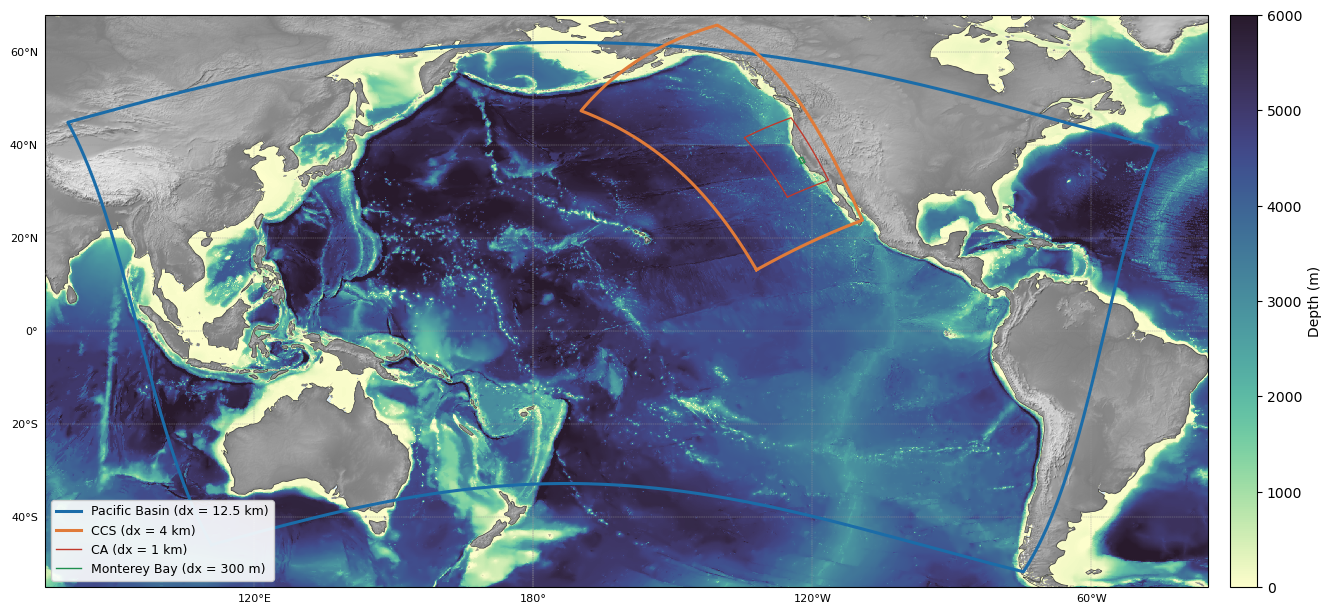

In [5]:
CENTRAL_LON = 200.0                       # Pacific-centered
EXTENT = (75, 325, -55, 68)               # lon_min, lon_max, lat_min, lat_max
VMAX = 6000                               # depth colorbar max (m)

# Draw outermost -> innermost so the small grids sit on top at overlaps.
DRAW_ORDER = ["pacific_12km", "ccs_4km", "ca_1km", "montereybay_300m"]

fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(projection=ccrs.PlateCarree(central_longitude=CENTRAL_LON))

lon_min, lon_max, lat_min, lat_max = EXTENT
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

pcm = plot_bathy(ax, lon_min, lon_max, lat_min, lat_max, CENTRAL_LON, vmax=VMAX)
# Grayscale relief land on top of the (land-masked) ocean bathymetry.
ax.add_feature(cartopy.feature.OCEAN, facecolor="#d6e6ef", zorder=-1)
ax.imshow(LAND_RGBA, extent=[-180, 180, -90, 90], origin="upper",
          transform=ccrs.PlateCarree(), zorder=2, regrid_shape=2200)
ax.coastlines(linewidth=0.5, color="0.25", zorder=3, resolution="110m")

handles = []
for gname in DRAW_ORDER:
    spec = GRID_SPECS[gname]
    kw = spec["grid_kwargs"]
    dx = kw["size_x"] / kw["nx"]
    elon, elat = grid_perimeter(GRIDS[gname], CENTRAL_LON)
    plot_perimeter(ax, elon, elat, color=spec["color"], linewidth=spec["lw"], zorder=5)
    handles.append(Line2D([0], [0], color=spec["color"], lw=spec["lw"],
                          label=f"{spec['label']} ({fmt_dx(dx)})"))

gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="0.6", linestyle="--")
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"fontsize": 8}
gl.ylabel_style = {"fontsize": 8}

ax.legend(handles=handles, loc="lower left", fontsize=9, framealpha=0.9)

# Match the colorbar height to the *actual* map height. A cartopy GeoAxes is
# resized to the map's aspect ratio after drawing, so a fixed `shrink` can't
# match it -- instead draw once, read the map's real position, and place the
# colorbar axes at exactly that y-extent and height.
fig.canvas.draw()
pos = ax.get_position()
cax = fig.add_axes([pos.x1 + 0.015, pos.y0, 0.018, pos.height])
cb = fig.colorbar(pcm, cax=cax)
cb.set_label("Depth (m)")

fig.savefig("cson-map-montereybay-nesting.png", dpi=150, bbox_inches="tight")
plt.show()

**Note on bathymetry:** ETOPO5 (5 arc-minute, ~9 km) is plotted at its native
resolution -- it is not regridded onto any of the four ROMS grids. At this
basin scale the two innermost footprints are small; the accompanying
`cson_grids_layout.ipynb` / zoomed views can be used to inspect the CA and
Monterey Bay nests up close.